# RTP Session Analysis — Google Meet & Microsoft Teams

Treats **each CSV** under `Sessions_18_to_19/{Meet,Teams}/` as one session and computes,
**per session**, a full metrics table plus three categories of plots.

- **Direction** is keyed on the **client** (IIT Delhi private IP, also in the filename
  `Session_<client_ip>_<epoch>.csv`): *uplink* = client→relay, *downlink* = relay→client.
  This is robust to relays that fall outside the published CIDR blocks; the ranges are
  used only to flag `remote_relay_in_known_range`.
- **Only sessions longer than 30 s are valid** — all plots and cross-session statistics
  use valid sessions only. The full CSV keeps every parsed session with a `valid_session` flag.
- `rtp_ssrc`/`rtp_timestamp` may be **hex** (`0xE9CE1A82`) — parsed per cell. Malformed
  rows/files never abort the batch.

**Outputs** (written under `analysis_output/`): the metrics CSV, per-session 6-panel
figures, cross-session scatter plots, and Teams-vs-Meet comparison plots
(grouped bars, boxplots, histograms, CDFs).

> Per-session figures are **saved to disk** (one high-res PNG each) rather than all
> rendered inline — with hundreds of sessions, inline rendering would overwhelm the
> notebook. A couple are previewed inline, and `show_session(id, ...)` displays any one.

## 1. Imports & configuration

In [ ]:
import os, re, glob, time
import ipaddress
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

# --- Data location (auto-detected; edit if needed) --------------------------
_CANDIDATE_ROOTS = ["Sessions_18_to_19", "../Sessions_18_to_19", "../../Sessions_18_to_19",
                    os.path.join("Meet","services","Analysis","Sessions_18_to_19")]
DATA_ROOT = next((p for p in _CANDIDATE_ROOTS
                  if os.path.isdir(os.path.join(p,"Meet")) or os.path.isdir(os.path.join(p,"Teams"))),
                 "Sessions_18_to_19")
print("DATA_ROOT =", DATA_ROOT)

# --- Output paths -----------------------------------------------------------
OUTPUT_DIR   = "analysis_output"
SUMMARY_CSV  = os.path.join(OUTPUT_DIR, "session_summary.csv")
ERRORS_CSV   = os.path.join(OUTPUT_DIR, "skipped_sessions.csv")
PER_SESSION_DIR = os.path.join(OUTPUT_DIR, "per_session_plots")
CROSS_DIR    = os.path.join(OUTPUT_DIR, "cross_session_plots")
COMPARE_DIR  = os.path.join(OUTPUT_DIR, "platform_comparison_plots")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Tunables ---------------------------------------------------------------
MIN_DURATION_S = 30.0                 # sessions must exceed this to be "valid"
AUDIO_VIDEO_UDP_THRESHOLD = 400       # udp_len < 400 -> audio, else video
BYTES_COL = "ip_len"                  # 'ip_len' (wire) or 'udp_len' (payload)
VIDEO_CLOCK_HZ = 90000
RTP_TS_MODULO = 2 ** 32
PLOT_DPI = 150

# --- Updated provider relay ranges (labeling only; direction uses client IP) -
# strict=False so non-aligned IPv6 prefixes (e.g. /22) don't raise.
RELAY_RANGES = {
    "Teams": ["52.112.0.0/14", "52.122.0.0/15",
              "2603:1063::/22", "2603:1027::/32", "2620:1ec:4::/48"],
    "Meet":  ["74.125.250.0/24", "74.125.247.128/32", "142.250.82.0/24",
              "2001:4860:4864:5::/64", "2001:4860:4864:6::/64",
              "2001:4860:4864:4:8000::/128"],
}
_ALL_RELAY_NETS = [ipaddress.ip_network(c, strict=False)
                   for cidrs in RELAY_RANGES.values() for c in cidrs]

DATA_ROOT = ../Sessions_18_to_19


## 2. IP helpers, hex parsing, direction & media classification

In [ ]:
def _ip(ip_str):
    try:
        return ipaddress.ip_address(str(ip_str).strip())
    except (ValueError, TypeError):
        return None

def is_relay_ip(ip_str):
    ip = _ip(ip_str)
    return bool(ip) and any(ip.version == n.version and ip in n for n in _ALL_RELAY_NETS)

def is_private_ip(ip_str):
    ip = _ip(ip_str)
    return bool(ip) and ip.is_private

In [3]:
def parse_int_column(s):
    """Parse cells that may be decimal or 0x-hex; bad cells -> <NA>. Int64 out."""
    s = s.astype("string").str.strip()
    is_hex = s.str.slice(0, 2).str.lower().eq("0x").fillna(False)
    out = pd.Series(pd.array([pd.NA] * len(s), dtype="Int64"), index=s.index)
    dec = (~is_hex) & s.notna() & (s.str.len() > 0)
    if dec.any():
        out.loc[dec] = pd.to_numeric(s[dec], errors="coerce").astype("Int64")
    if is_hex.any():
        parsed = []
        for v in s[is_hex].to_list():
            try:
                parsed.append(int(v, 16))
            except (ValueError, TypeError):
                parsed.append(pd.NA)
        out.loc[is_hex] = pd.array(parsed, dtype="Int64")
    return out

In [4]:
def get_client_ip(path, df):
    endpoints = set(pd.unique(df["src_ip"].dropna())) | set(pd.unique(df["dst_ip"].dropna()))
    name = re.sub(r"\.csv$", "", os.path.basename(path), flags=re.IGNORECASE)
    parts = name.split("_")
    if len(parts) >= 3 and _ip(parts[1]) is not None and parts[1] in endpoints:
        return parts[1]
    privs = [ip for ip in endpoints if is_private_ip(ip)]
    if len(privs) == 1:
        return privs[0]
    if privs:
        counts = {ip: int(((df["src_ip"] == ip) | (df["dst_ip"] == ip)).sum()) for ip in privs}
        return max(counts, key=counts.get)
    nonrelay = [ip for ip in endpoints if not is_relay_ip(ip)]
    return nonrelay[0] if len(nonrelay) == 1 else None

def classify_direction(df, client_ip):
    out = df.copy()
    if out.empty or client_ip is None:
        out["direction"] = pd.Series(["other"] * len(out), dtype="object")
        return out
    src_c = (out["src_ip"] == client_ip).to_numpy()
    dst_c = (out["dst_ip"] == client_ip).to_numpy()
    d = np.full(len(out), "other", dtype=object)
    d[src_c & ~dst_c] = "uplink"
    d[dst_c & ~src_c] = "downlink"
    out["direction"] = d
    return out

def classify_media(df):
    out = df.copy()
    out["media"] = np.where(out["udp_len"].astype("float64") < AUDIO_VIDEO_UDP_THRESHOLD,
                            "audio", "video")
    return out

## 3. Scalar metric helpers (throughput, bitrate, FPS, jitter)

In [ ]:
import math

def _safe_div(num, den):
    if den is None or den == 0 or not np.isfinite(den):
        return np.nan
    return num / den

def _rel_sec(arr_ns, t0):
    return ((arr_ns - t0) // 1_000_000_000).astype("int64")

def throughput_timeseries(sub, t0=None):
    """1-second binned throughput (bits/s). Optional shared t0 for alignment."""
    if sub.empty:
        return np.array([]), np.array([])
    if t0 is None:
        t0 = sub["arrival_epoch_ns"].min()
    rel = _rel_sec(sub["arrival_epoch_ns"], t0)
    bits = sub[BYTES_COL].astype("float64") * 8.0
    b = bits.groupby(rel).sum()
    full = np.arange(b.index.min(), b.index.max() + 1)
    b = b.reindex(full, fill_value=0.0)
    return b.index.to_numpy(), b.to_numpy()

def throughput_stats(sub):
    """(mean, peak) in Mbps from 1-second bins."""
    _, bps = throughput_timeseries(sub)
    if bps.size == 0:
        return np.nan, np.nan
    return float(np.mean(bps)) / 1e6, float(np.max(bps)) / 1e6

def average_bitrate(sub):
    if sub.empty:
        return np.nan
    bits = sub[BYTES_COL].astype("float64").sum() * 8.0
    span = (sub["arrival_epoch_ns"].max() - sub["arrival_epoch_ns"].min()) / 1e9
    return _safe_div(bits, span) / 1e6 if span > 0 else np.nan

def unwrap_rtp_timestamp(ts_values):
    ts = np.asarray(ts_values, dtype="int64")
    if ts.size <= 1:
        return ts.astype("float64")
    diffs = np.diff(ts)
    wrap = np.where(diffs < -(RTP_TS_MODULO // 2), RTP_TS_MODULO, 0)
    return ts.astype("float64") + np.concatenate([[0], np.cumsum(wrap)])

def dominant_video_ssrc(video_sub):
    return None if video_sub.empty else video_sub["rtp_ssrc"].value_counts().idxmax()

def marker_arrival_times_s(sub):
    m = sub[sub["rtp_marker"] == 1]
    if m.empty:
        return np.array([])
    return np.sort(m["arrival_epoch_ns"].to_numpy().astype("float64")) / 1e9

# Keep original name so nothing breaks
def fps_method1_timestamp(sub):
    """FPS from dominant SSRC."""
    if sub.empty:
        return np.nan
    o = sub.sort_values("arrival_epoch_ns")
    ts = unwrap_rtp_timestamp(o["rtp_timestamp"].to_numpy())
    n = np.unique(o["rtp_timestamp"].to_numpy()).size
    return _safe_div(n, (ts[-1] - ts[0]) / VIDEO_CLOCK_HZ)

# Keep original name as legacy reference
def frame_jitter_ms(sub):
    """LEGACY: abs(diff(diff())) on marker-bit arrivals."""
    t = marker_arrival_times_s(sub)
    if t.size < 3:
        return np.nan, np.nan, np.nan, np.nan
    iv = np.diff(t) * 1000.0
    j = np.abs(np.diff(iv))
    if j.size == 0:
        return np.nan, np.nan, np.nan, np.nan
    return float(np.mean(j)), float(np.median(j)), float(np.percentile(j, 95)), float(np.max(j))

# ── NEW: Matches Rust media_metrics.rs ──────────────────────────────────────

def _compute_stream_jitter_and_fps(video_ssrc_sub, duration_s):
    """
    Per-SSRC jitter & FPS matching Rust media_metrics.rs:
    1. Unique rtp_timestamp -> first arrival (HashMap equivalent)
    2. Sort by rtp_timestamp
    3. Only include arrival gaps where RTP ts gap is in [MIN_GAP, MAX_GAP]
    4. FPS = unique_frames / duration
    5. Jitter = std_dev of valid arrival gaps (ms)
    """
    if video_ssrc_sub.empty or duration_s <= 0:
        return np.nan, np.nan, False

    sorted_sub = video_ssrc_sub.sort_values("arrival_epoch_ns")
    frame_arrivals = sorted_sub.groupby("rtp_timestamp")["arrival_epoch_ns"].first()

    if len(frame_arrivals) < 2:
        return np.nan, np.nan, False

    frame_arrivals = frame_arrivals.sort_index()
    rtp_ts_arr = frame_arrivals.index.to_numpy().astype("uint32")
    arrival_arr = frame_arrivals.values.astype("int64")

    valid_gap_count = 0
    arrival_gaps_ms = []

    for i in range(1, len(rtp_ts_arr)):
        rtp_gap = int(np.uint32(rtp_ts_arr[i]) - np.uint32(rtp_ts_arr[i - 1]))
        if rtp_gap < 0:
            rtp_gap += 2**32
        if MIN_GAP <= rtp_gap <= MAX_GAP:
            valid_gap_count += 1
            gap_ns = max(0, arrival_arr[i] - arrival_arr[i - 1])
            arrival_gaps_ms.append(gap_ns / 1_000_000.0)

    if valid_gap_count == 0:
        return np.nan, np.nan, False

    stream_fps = len(frame_arrivals) / duration_s

    if len(arrival_gaps_ms) == 0:
        return stream_fps, 0.0, True

    mean_gap = sum(arrival_gaps_ms) / len(arrival_gaps_ms)
    variance = sum((g - mean_gap) ** 2 for g in arrival_gaps_ms) / len(arrival_gaps_ms)
    stream_jitter = math.sqrt(variance)

    return stream_fps, stream_jitter, True

def fps_method2_counting(sub):
    """Marker-bit based FPS counting."""
    t = marker_arrival_times_s(sub)
    if t.size < 2:
        return np.nan, np.nan, np.nan
    idx = np.floor(t - t[0]).astype("int64")
    c = pd.Series(1, index=idx).groupby(level=0).sum()
    full = np.arange(c.index.min(), c.index.max() + 1)
    v = c.reindex(full, fill_value=0).to_numpy().astype("float64")
    if v.size >= 3:
        v = v[1:-1]
    if v.size == 0:
        return np.nan, np.nan, np.nan
    return float(np.mean(v)), float(np.median(v)), float(np.max(v))

def video_quality_metrics(video_dir_sub, duration_s=None):
    """FPS + Jitter across ALL valid video SSRCs (matching Rust)."""
    keys = ["fps_m1", "fps_m2_mean", "fps_m2_median", "fps_m2_max",
            "jitter_mean_ms", "jitter_median_ms", "jitter_p95_ms",
            "jitter_max_ms", "n_video_ssrc"]
    r = {k: np.nan for k in keys}

    if video_dir_sub.empty:
        r["n_video_ssrc"] = 0
        return r, None

    r["n_video_ssrc"] = video_dir_sub["rtp_ssrc"].nunique()

    if duration_s is None or duration_s <= 0:
        t_min = video_dir_sub["arrival_epoch_ns"].min()
        t_max = video_dir_sub["arrival_epoch_ns"].max()
        duration_s = (t_max - t_min) / 1e9
        if duration_s <= 0:
            return r, None

    total_fps = 0.0
    total_jitter = 0.0
    valid_count = 0
    per_stream_jitters = []

    for ssrc, ssrc_sub in video_dir_sub.groupby("rtp_ssrc"):
        fps, jitter, is_valid = _compute_stream_jitter_and_fps(ssrc_sub, duration_s)
        if is_valid:
            total_fps += fps
            total_jitter += jitter
            valid_count += 1
            per_stream_jitters.append(jitter)

    if valid_count > 0:
        r["fps_m1"] = total_fps / valid_count
        r["jitter_mean_ms"] = total_jitter / valid_count
        jarr = np.array(per_stream_jitters)
        r["jitter_median_ms"] = float(np.median(jarr))
        r["jitter_p95_ms"] = float(np.percentile(jarr, 95)) if len(jarr) >= 2 else float(jarr[0])
        r["jitter_max_ms"] = float(np.max(jarr))

    dom_ssrc = dominant_video_ssrc(video_dir_sub)
    dom_sub = video_dir_sub[video_dir_sub["rtp_ssrc"] == dom_ssrc] if dom_ssrc is not None else video_dir_sub
    r["fps_m2_mean"], r["fps_m2_median"], r["fps_m2_max"] = fps_method2_counting(dom_sub)

    return r, dom_sub

# ── NEW: Packet Loss (matches Rust network_metrics.rs) ──────────────────────

def packet_loss(direction_sub):
    """Packet loss with out-of-order handling. Returns (received, lost, loss_pct)"""
    if direction_sub.empty:
        return 0, 0, 0.0

    sorted_sub = direction_sub.sort_values("arrival_epoch_ns")
    last_seq = {}
    total_received = 0
    total_lost = 0

    for _, row in sorted_sub.iterrows():
        ssrc = row["rtp_ssrc"]
        seq = int(row["rtp_seq"]) & 0xFFFF
        total_received += 1

        if ssrc in last_seq:
            diff = (seq - last_seq[ssrc]) & 0xFFFF
            if diff > 32767:
                diff -= 65536
            if diff > 0:
                if diff > 1:
                    total_lost += min(diff - 1, 1000)
                last_seq[ssrc] = seq
            elif diff < 0 and diff > -100:
                total_lost = max(0, total_lost - 1)
        else:
            last_seq[ssrc] = seq

    expected = total_received + total_lost
    loss_pct = (total_lost / expected * 100.0) if expected > 0 else 0.0
    return total_received, total_lost, loss_pct

def packet_loss_timeseries(direction_sub, t0):
    """Per-second packet loss % for plotting."""
    if direction_sub.empty:
        return np.array([]), np.array([])

    from collections import defaultdict
    sorted_sub = direction_sub.sort_values("arrival_epoch_ns")
    rel = _rel_sec(sorted_sub["arrival_epoch_ns"], t0)

    received_per_sec = defaultdict(int)
    lost_per_sec = defaultdict(int)
    last_seq = {}

    for idx in range(len(sorted_sub)):
        row = sorted_sub.iloc[idx]
        sec = int(rel.iloc[idx])
        ssrc = row["rtp_ssrc"]
        seq = int(row["rtp_seq"]) & 0xFFFF

        received_per_sec[sec] += 1

        if ssrc in last_seq:
            diff = (seq - last_seq[ssrc]) & 0xFFFF
            if diff > 32767:
                diff -= 65536
            if diff > 0:
                if diff > 1:
                    lost_per_sec[sec] += min(diff - 1, 1000)
                last_seq[ssrc] = seq
            elif diff < 0 and diff > -100:
                lost_per_sec[sec] = max(0, lost_per_sec[sec] - 1)
        else:
            last_seq[ssrc] = seq

    if not received_per_sec:
        return np.array([]), np.array([])

    all_secs = sorted(set(received_per_sec.keys()) | set(lost_per_sec.keys()))
    full_range = np.arange(min(all_secs), max(all_secs) + 1)

    loss_pcts = np.zeros(len(full_range))
    for i, sec in enumerate(full_range):
        r = received_per_sec.get(sec, 0)
        l = lost_per_sec.get(sec, 0)
        expected = r + l
        loss_pcts[i] = (l / expected * 100.0) if expected > 0 else 0.0

    return full_range, loss_pcts

## 4. Time-series helpers for per-session plots
A shared `t0` (session start) aligns uplink and downlink on the same x-axis.

In [ ]:
def _mbps_series(sub, t0):
    s, b = throughput_timeseries(sub, t0)
    return s, (b / 1e6 if b.size else b)

def fps_m1_timeseries(sub, t0):
    """Per-second distinct-RTP-timestamp count (timestamp-based FPS over time)."""
    if sub.empty:
        return np.array([]), np.array([])
    rel = _rel_sec(sub["arrival_epoch_ns"], t0)
    g = sub.groupby(rel)["rtp_timestamp"].nunique()
    full = np.arange(g.index.min(), g.index.max() + 1)
    g = g.reindex(full, fill_value=0)
    return g.index.to_numpy(), g.to_numpy().astype("float64")

def fps_m2_timeseries(sub, t0):
    """Per-second marker-bit count (frame-counting FPS over time)."""
    m = sub[sub["rtp_marker"] == 1]
    if m.empty:
        return np.array([]), np.array([])
    rel = _rel_sec(m["arrival_epoch_ns"], t0)
    c = m.groupby(rel).size()
    full = np.arange(c.index.min(), c.index.max() + 1)
    c = c.reindex(full, fill_value=0)
    return c.index.to_numpy(), c.to_numpy().astype("float64")

def jitter_timeseries(video_dir_sub, t0):
    """Per-second frame jitter (std_dev, valid RTP gaps only). Matches Rust."""
    if video_dir_sub.empty:
        return np.array([]), np.array([])

    from collections import defaultdict
    sorted_sub = video_dir_sub.sort_values("arrival_epoch_ns")
    rel = _rel_sec(sorted_sub["arrival_epoch_ns"], t0)

    frame_data = defaultdict(lambda: defaultdict(dict))
    for idx in range(len(sorted_sub)):
        row = sorted_sub.iloc[idx]
        sec = int(rel.iloc[idx])
        ssrc = row["rtp_ssrc"]
        rtp_ts = int(row["rtp_timestamp"]) & 0xFFFFFFFF
        arrival = int(row["arrival_epoch_ns"])
        if rtp_ts not in frame_data[sec][ssrc]:
            frame_data[sec][ssrc][rtp_ts] = arrival

    if not frame_data:
        return np.array([]), np.array([])

    all_secs = sorted(frame_data.keys())
    full_range = np.arange(min(all_secs), max(all_secs) + 1)
    jitter_vals = np.full(len(full_range), np.nan)

    for i, sec in enumerate(full_range):
        if sec not in frame_data:
            continue
        total_jitter = 0.0
        valid_streams = 0
        for ssrc, frames in frame_data[sec].items():
            if len(frames) < 2:
                continue
            sorted_frames = sorted(frames.items(), key=lambda x: x[0])
            rtp_ts_arr = [f[0] for f in sorted_frames]
            arrival_arr = [f[1] for f in sorted_frames]

            gaps_ms = []
            for j in range(1, len(rtp_ts_arr)):
                rtp_gap = (rtp_ts_arr[j] - rtp_ts_arr[j-1]) & 0xFFFFFFFF
                if MIN_GAP <= rtp_gap <= MAX_GAP:
                    gap_ns = max(0, arrival_arr[j] - arrival_arr[j-1])
                    gaps_ms.append(gap_ns / 1_000_000.0)

            if not gaps_ms:
                continue

            mean_gap = sum(gaps_ms) / len(gaps_ms)
            variance = sum((g - mean_gap) ** 2 for g in gaps_ms) / len(gaps_ms)
            stream_jitter = math.sqrt(variance)
            total_jitter += stream_jitter
            valid_streams += 1

        if valid_streams > 0:
            jitter_vals[i] = total_jitter / valid_streams

    return full_range, jitter_vals

## 5. Loading, per-session analysis & batch driver

In [7]:
REQUIRED_COLUMNS = ['arrival_epoch_ns', 'src_ip', 'dst_ip', 'ip_proto', 'ip_len', 'src_port', 'dst_port', 'udp_len', 'rtp_ssrc', 'rtp_timestamp', 'rtp_seq', 'rtp_pt', 'rtp_marker']

In [ ]:
def load_session_csv(path):
    df = pd.read_csv(path, dtype="string")
    missing = [c for c in REQUIRED_COLUMNS if c not in df.columns]
    if missing:
        raise ValueError(f"{os.path.basename(path)} missing columns: {missing}")
    for c in ["arrival_epoch_ns", "rtp_ssrc", "rtp_timestamp", "rtp_seq",
              "rtp_pt", "rtp_marker", "ip_len", "udp_len", "src_port", "dst_port"]:
        df[c] = parse_int_column(df[c])
    df = df.dropna(subset=["arrival_epoch_ns", "rtp_ssrc", "rtp_timestamp"]).copy()
    df["arrival_epoch_ns"] = df["arrival_epoch_ns"].astype("int64")
    df["rtp_ssrc"] = df["rtp_ssrc"].astype("int64")
    df["rtp_timestamp"] = df["rtp_timestamp"].astype("int64")
    df["rtp_seq"] = df["rtp_seq"].fillna(0).astype("int64")
    df["rtp_marker"] = df["rtp_marker"].fillna(0).astype("int64")
    for c in ["ip_len", "udp_len"]:
        df[c] = df[c].fillna(0).astype("int64")
    df["src_ip"] = df["src_ip"].astype("string")
    df["dst_ip"] = df["dst_ip"].astype("string")
    return df.sort_values("arrival_epoch_ns").reset_index(drop=True)

def analyze_session(path, provider):
    df = load_session_csv(path)
    if df.empty:
        raise ValueError("no usable RTP rows after parsing")
    client_ip = get_client_ip(path, df)
    df = classify_media(classify_direction(df, client_ip))
    t0 = int(df["arrival_epoch_ns"].min())
    t_end = int(df["arrival_epoch_ns"].max())
    dur = (t_end - t0) / 1e9

    up, down = df[df["direction"] == "uplink"], df[df["direction"] == "downlink"]
    up_v, down_v = up[up.media == "video"], down[down.media == "video"]
    up_a, down_a = up[up.media == "audio"], down[down.media == "audio"]

    up_thr_mean, up_thr_peak = throughput_stats(up)
    dn_thr_mean, dn_thr_peak = throughput_stats(down)
    up_vbr_mean, up_vbr_peak = throughput_stats(up_v)
    dn_vbr_mean, dn_vbr_peak = throughput_stats(down_v)

    upq, up_dom = video_quality_metrics(up_v, dur)
    dnq, dn_dom = video_quality_metrics(down_v, dur)

    # Packet Loss (NEW)
    up_received, up_lost, up_loss_pct = packet_loss(up)
    dn_received, dn_lost, dn_loss_pct = packet_loss(down)

    remote = sorted(set(pd.unique(df["src_ip"].dropna())) | set(pd.unique(df["dst_ip"].dropna())) - {client_ip})
    row = {
        "session_id": re.sub(r"\.csv$", "", os.path.basename(path), flags=re.IGNORECASE),
        "session": os.path.basename(path),
        "platform": provider,
        "client_ip": client_ip,
        "remote_relay_in_known_range": any(is_relay_ip(ip) for ip in remote if ip != client_ip),
        "start_time": pd.to_datetime(t0, unit="ns", utc=True),
        "end_time": pd.to_datetime(t_end, unit="ns", utc=True),
        "duration_s": dur,
        "valid_session": dur > MIN_DURATION_S,
        "n_packets": len(df),
        "n_uplink_pkts": len(up),
        "n_downlink_pkts": len(down),
        "uplink_throughput_mbps": up_thr_mean,
        "downlink_throughput_mbps": dn_thr_mean,
        "uplink_throughput_peak_mbps": up_thr_peak,
        "downlink_throughput_peak_mbps": dn_thr_peak,
        "uplink_video_bitrate_mbps": average_bitrate(up_v),
        "downlink_video_bitrate_mbps": average_bitrate(down_v),
        "uplink_video_bitrate_peak_mbps": up_vbr_peak,
        "downlink_video_bitrate_peak_mbps": dn_vbr_peak,
        "uplink_audio_bitrate_mbps": average_bitrate(up_a),
        "downlink_audio_bitrate_mbps": average_bitrate(down_a),
        "uplink_jitter_ms": upq["jitter_mean_ms"],
        "downlink_jitter_ms": dnq["jitter_mean_ms"],
        "uplink_jitter_max_ms": upq["jitter_max_ms"],
        "downlink_jitter_max_ms": dnq["jitter_max_ms"],
        "uplink_jitter_p95_ms": upq["jitter_p95_ms"],
        "downlink_jitter_p95_ms": dnq["jitter_p95_ms"],
        "uplink_fps_m1": upq["fps_m1"],
        "downlink_fps_m1": dnq["fps_m1"],
        "uplink_fps_m2": upq["fps_m2_mean"],
        "downlink_fps_m2": dnq["fps_m2_mean"],
        "uplink_n_video_ssrc": upq["n_video_ssrc"],
        "downlink_n_video_ssrc": dnq["n_video_ssrc"],
        # Packet Loss (NEW columns)
        "uplink_loss_pct": up_loss_pct,
        "downlink_loss_pct": dn_loss_pct,
        "uplink_lost_pkts": up_lost,
        "downlink_lost_pkts": dn_lost,
    }

    ts = None
    if row["valid_session"]:
        ts = {
            "throughput": {"up": _mbps_series(up, t0), "down": _mbps_series(down, t0)},
            "video_bitrate": {"up": _mbps_series(up_v, t0), "down": _mbps_series(down_v, t0)},
            "audio_bitrate": {"up": _mbps_series(up_a, t0), "down": _mbps_series(down_a, t0)},
            "fps_m1": {
                "up": fps_m1_timeseries(up_dom, t0) if up_dom is not None else (np.array([]), np.array([])),
                "down": fps_m1_timeseries(dn_dom, t0) if dn_dom is not None else (np.array([]), np.array([])),
            },
            "fps_m2": {
                "up": fps_m2_timeseries(up_dom, t0) if up_dom is not None else (np.array([]), np.array([])),
                "down": fps_m2_timeseries(dn_dom, t0) if dn_dom is not None else (np.array([]), np.array([])),
            },
            "jitter": {
                "up": jitter_timeseries(up_v, t0),
                "down": jitter_timeseries(down_v, t0),
            },
            "packet_loss": {
                "up": packet_loss_timeseries(up, t0),
                "down": packet_loss_timeseries(down, t0),
            },
        }
    return row, ts

def process_all(data_root=DATA_ROOT, checkpoint_every=50,
                checkpoint_csv=SUMMARY_CSV, errors_csv=ERRORS_CSV):
    """Analyze all CSVs with live progress, checkpoints and a summary report."""
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    jobs = []
    for provider in ("Meet", "Teams"):
        folder = os.path.join(data_root, provider)
        if not os.path.isdir(folder):
            print(f"[skip] folder not found: {folder}"); continue
        files = sorted(glob.glob(os.path.join(folder, "*.csv")))
        print(f"{provider}: found {len(files)} CSV file(s)")
        jobs += [(provider, p) for p in files]

    total = len(jobs)
    rows, store, errors = [], {}, []
    if total == 0:
        print("No CSV files found under", data_root)
        return pd.DataFrame(), store, pd.DataFrame()

    print(f"\nProcessing {total} session(s)…\n")
    t_start = time.time(); total_pkts = 0
    try:
        from tqdm.auto import tqdm
        bar, use_tqdm = tqdm(total=total, desc="Sessions", unit="file"), True
    except Exception:
        bar, use_tqdm = None, False
    log = (lambda m: bar.write(m)) if use_tqdm else print

    for i, (provider, path) in enumerate(jobs, 1):
        name = os.path.basename(path)
        try:
            row, ts = analyze_session(path, provider)
            rows.append(row)
            if ts is not None:
                store[row["session_id"]] = ts
            total_pkts += int(row["n_packets"]); status = "ok"
        except Exception as exc:
            errors.append({"provider": provider, "session": name,
                           "error_type": type(exc).__name__, "error": str(exc)})
            status = "ERR"; log(f"  [error] {name}: {type(exc).__name__}: {exc}")
        elapsed = time.time() - t_start
        rate = i / elapsed if elapsed > 0 else 0.0
        eta = (total - i) / rate if rate > 0 else float("nan")
        if use_tqdm:
            bar.update(1)
            bar.set_postfix_str(f"ok={len(rows)} err={len(errors)} pkts={total_pkts:,} | {provider}:{name[:20]}")
        else:
            print(f"\r[{i:>5}/{total}] ({total-i:>5} left) ok={len(rows)} err={len(errors)} "
                  f"pkts={total_pkts:,} ETA={eta:5.0f}s | {status} {provider} {name[:34]:<34}", end="", flush=True)
        if checkpoint_every and i % checkpoint_every == 0 and rows:
            pd.DataFrame(rows).to_csv(checkpoint_csv, index=False)
            if errors:
                pd.DataFrame(errors).to_csv(errors_csv, index=False)
            log(f"  …checkpoint: {len(rows)} rows -> {checkpoint_csv}")
    if use_tqdm:
        bar.close()
    else:
        print()

    summary = pd.DataFrame(rows); err_df = pd.DataFrame(errors)
    if not summary.empty:
        summary.to_csv(checkpoint_csv, index=False)
    if not err_df.empty:
        err_df.to_csv(errors_csv, index=False)

    elapsed = time.time() - t_start
    n_valid = int(summary["valid_session"].sum()) if not summary.empty else 0
    print("\n" + "=" * 64)
    print(f"Done in {elapsed:,.1f}s  ({elapsed/max(total,1):.2f}s/file)")
    print(f"  sessions parsed : {len(rows)}   (skipped: {len(errors)}, total files: {total})")
    print(f"  valid (>{MIN_DURATION_S:.0f}s)   : {n_valid}")
    print(f"  packets         : {total_pkts:,}")
    for prov in ("Meet", "Teams"):
        if not summary.empty:
            sp = summary[summary.platform == prov]
            print(f"  {prov:<6}: {len(sp)} parsed, {int(sp['valid_session'].sum())} valid")
    if not err_df.empty:
        print("\nSkipped by error type:")
        for et, c in err_df["error_type"].value_counts().items():
            print(f"  {et}: {c}")
        print(f"(full list -> {errors_csv})")
    print("=" * 64)
    return summary, store, err_df

In [9]:
SUMMARY_COLUMNS = ['session_id', 'platform', 'start_time', 'end_time', 'duration_s', 'uplink_throughput_mbps', 'downlink_throughput_mbps', 'uplink_video_bitrate_mbps', 'downlink_video_bitrate_mbps', 'uplink_audio_bitrate_mbps', 'downlink_audio_bitrate_mbps', 'uplink_jitter_ms', 'downlink_jitter_ms', 'uplink_fps_m1', 'downlink_fps_m1', 'uplink_fps_m2', 'downlink_fps_m2']

def build_summary_table(summary_df, valid_only=True):
    if summary_df.empty:
        return summary_df
    df = summary_df[summary_df["valid_session"]] if valid_only else summary_df
    return df[SUMMARY_COLUMNS].reset_index(drop=True)

## 6. Run the analysis (live progress + checkpoints)

In [10]:
# Preflight: ensure the definition cells above were run (avoids cryptic NameError).
_needed = ["parse_int_column","get_client_ip","classify_direction","classify_media",
           "load_session_csv","analyze_session","process_all","build_summary_table"]
_missing = [f for f in _needed if f not in globals()]
if _missing:
    raise NameError("Run the cells above first (menu: Run -> Run All Cells). "
                    "Missing: " + ", ".join(_missing))
print("Preflight OK.")

Preflight OK.


In [11]:
# checkpoint_every: re-save the CSV every N files (crash-safe). Lower for huge runs.
summary_df, ts_store, errors_df = process_all(DATA_ROOT, checkpoint_every=50)
print(f"\nFull metrics CSV (all parsed sessions) -> {SUMMARY_CSV}")

/home/netmon/miniconda3/envs/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Meet: found 513 CSV file(s)
Teams: found 78 CSV file(s)

Processing 591 session(s)…



Sessions:   8%|▊         | 50/591 [06:14<1:38:47, 10.96s/file, ok=50 err=0 pkts=23,155,799 | Meet:Session_10.184.119.1]

  …checkpoint: 50 rows -> analysis_output/session_summary.csv


Sessions:  17%|█▋        | 101/591 [07:54<09:40,  1.19s/file, ok=101 err=0 pkts=29,527,052 | Meet:Session_10.184.17.23]

...

  …checkpoint: 500 rows -> analysis_output/session_summary.csv


Sessions:  94%|█████████▍| 555/591 [46:10<00:54,  1.51s/file, ok=555 err=0 pkts=172,751,344 | Teams:Session_10.184.40.24]

  …checkpoint: 550 rows -> analysis_output/session_summary.csv


Sessions: 100%|██████████| 591/591 [48:05<00:00,  4.88s/file, ok=591 err=0 pkts=180,021,729 | Teams:Session_2001_df4_e00]


Done in 2,885.4s  (4.88s/file)
  sessions parsed : 591   (skipped: 0, total files: 591)
  valid (>30s)   : 480
  packets         : 180,021,729
  Meet  : 513 parsed, 421 valid
  Teams : 78 parsed, 59 valid

Full metrics CSV (all parsed sessions) -> analysis_output/session_summary.csv


## 7. Session summary table
The exact required columns, **valid sessions only**. The full CSV (every parsed session,
with the `valid_session` flag and extra peak/percentile columns) is at `SUMMARY_CSV`.

In [12]:
pd.set_option("display.max_columns", None); pd.set_option("display.width", 260)
summary_table = build_summary_table(summary_df, valid_only=True)
print(f"{len(summary_table)} valid session(s) of {len(summary_df)} parsed")
summary_table

480 valid session(s) of 591 parsed


,session_id,platform,start_time,end_time,duration_s,uplink_throughput_mbps,downlink_throughput_mbps,uplink_video_bitrate_mbps,downlink_video_bitrate_mbps,uplink_audio_bitrate_mbps,downlink_audio_bitrate_mbps,uplink_jitter_ms,downlink_jitter_ms,uplink_fps_m1,downlink_fps_m1,uplink_fps_m2,downlink_fps_m2
0,Session_10.184.0.102_1781777070551667106,Meet,2026-06-18 10:04:30.551667106+00:00,2026-06-18 10:08:13.898132888+00:00,223.346466,0.901029,0.015454,0.903229,NaN,0.067664,0.015486,18.503546,NaN,20.516993,NaN,20.502439,NaN
1,Session_10.184.0.80_1781792930719904605,Meet,2026-06-18 14:28:50.719904605+00:00,2026-06-18 14:30:15.275934124+00:00,84.556030,2.096406,0.011654,2.428243,NaN,0.028786,0.012538,22.241353,NaN,20.052923,NaN,20.253521,NaN
2,Session_10.184.1.234_1781797547045029577,Meet,2026-06-18 15:45:47.045029577+00:00,2026-06-18 16:00:08.497297563+00:00,861.452268,0.829127,0.551706,0.797379,0.527452,0.036887,0.024553,25.634648,22.585340,16.169275,22.360882,16.183626,22.381481
3,Session_10.184.10.74_1781785891780866942,Meet,2026-06-18 12:31:31.780866942+00:00,2026-06-18 12:44:36.880308549+00:00,785.099442,0.014388,0.457689,NaN,0.698425,0.014392,0.001282,NaN,54.900835,NaN,18.332689,NaN,18.314985
4,Session_10.184.10.99_1781775048582157766,Meet,2026-06-18 09:30:48.582157766+00:00,2026-06-18 09:38:44.722574390+00:00,476.140417,0.387319,0.002780,0.606615,NaN,0.046183,0.002785,11.110284,NaN,27.287142,NaN,27.262500,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,Session_2001_df4_e000_3fd2_4cd9_e7b7_7681_94bc...,Teams,2026-06-19 09:05:43.818845931+00:00,2026-06-19 09:18:43.124390901+00:00,779.305545,2.223424,0.055955,2.242229,0.008263,0.020016,0.047849,18.996917,3048.988707,28.155019,0.535254,28.195739,0.423841
476,Session_2001_df4_e000_3fd2_6d60_811f_79f7_cfcd...,Teams,2026-06-19 06:55:59.397657578+00:00,2026-06-19 08:22:08.903752201+00:00,5169.506095,0.957592,2.472685,0.998170,2.347439,0.024639,0.125579,73.782499,13.204288,14.414517,26.435840,14.410729,26.426686
477,Session_2001_df4_e000_3fd2_80a8_58e9_c4d_b74f_...,Teams,2026-06-18 09:31:14.256894234+00:00,2026-06-18 09:59:05.973996898+00:00,1671.717103,1.261215,0.035180,1.245695,NaN,0.016267,0.035198,25.252991,NaN,25.412335,NaN,25.424924,NaN
478,Session_2001_df4_e000_3fd2_9ded_110d_8c00_511c...,Teams,2026-06-19 06:33:19.034399219+00:00,2026-06-19 06:34:29.185180506+00:00,70.150781,1.608197,2.397700,1.619559,2.836239,0.045251,0.083193,47.943366,7.768157,24.321853,29.992995,24.583333,29.946429


### Skipped files (if any) — also saved to `skipped_sessions.csv`

In [13]:
errors_df if not errors_df.empty else "No files were skipped."

'No files were skipped.'

## 8. Plotting functions

In [14]:
def set_plot_style():
    """Publication-quality defaults: large fonts, grid, high-res."""
    plt.rcParams.update({
        "figure.dpi": 110, "savefig.dpi": PLOT_DPI,
        "font.size": 13, "axes.titlesize": 15, "axes.titleweight": "bold",
        "axes.labelsize": 13, "legend.fontsize": 11,
        "xtick.labelsize": 11, "ytick.labelsize": 11,
        "axes.grid": True, "grid.alpha": 0.3, "lines.linewidth": 1.8,
        "figure.autolayout": False,
    })

In [ ]:
def _line(ax, xy, label, **kw):
    x, y = xy
    if x is not None and len(x):
        ax.plot(x, y, label=label, **kw)

def plot_session(row, ts, save_dir=None, show=False):
    """8 stacked plots (throughput, video/audio bitrate, FPS m1/m2, jitter, packet loss)
    with uplink & downlink overlaid. Saves a high-res PNG and/or shows it."""
    sid, plat = row["session_id"], row["platform"]
    fig, axes = plt.subplots(4, 2, figsize=(15, 16))
    fig.suptitle(f"{plat}  |  Session {sid}  |  {row['duration_s']:.1f}s",
                 fontsize=17, fontweight="bold")

    ax = axes[0, 0]
    _line(ax, ts["throughput"]["up"], "Uplink", color="tab:blue")
    _line(ax, ts["throughput"]["down"], "Downlink", color="tab:red")
    ax.set_title("Throughput"); ax.set_xlabel("Time (s)"); ax.set_ylabel("Throughput (Mbps)"); ax.legend()

    ax = axes[0, 1]
    _line(ax, ts["video_bitrate"]["up"], "Uplink", color="tab:blue")
    _line(ax, ts["video_bitrate"]["down"], "Downlink", color="tab:red")
    ax.set_title("Video Bitrate"); ax.set_xlabel("Time (s)"); ax.set_ylabel("Bitrate (Mbps)"); ax.legend()

    ax = axes[1, 0]
    _line(ax, ts["audio_bitrate"]["up"], "Uplink", color="tab:blue")
    _line(ax, ts["audio_bitrate"]["down"], "Downlink", color="tab:red")
    ax.set_title("Audio Bitrate"); ax.set_xlabel("Time (s)"); ax.set_ylabel("Bitrate (Mbps)"); ax.legend()

    ax = axes[1, 1]
    _line(ax, ts["fps_m1"]["up"], "Uplink", color="tab:blue", marker=".", ms=4)
    _line(ax, ts["fps_m1"]["down"], "Downlink", color="tab:red", marker=".", ms=4)
    ax.set_title("FPS — Method 1 (RTP timestamp)"); ax.set_xlabel("Time (s)"); ax.set_ylabel("Frames / s"); ax.legend()

    ax = axes[2, 0]
    _line(ax, ts["fps_m2"]["up"], "Uplink", color="tab:blue", marker=".", ms=4)
    _line(ax, ts["fps_m2"]["down"], "Downlink", color="tab:red", marker=".", ms=4)
    ax.set_title("FPS — Method 2 (marker bit)"); ax.set_xlabel("Time (s)"); ax.set_ylabel("Frames / s"); ax.legend()

    ax = axes[2, 1]
    _line(ax, ts["jitter"]["up"], "Uplink", color="tab:blue", alpha=0.85)
    _line(ax, ts["jitter"]["down"], "Downlink", color="tab:red", alpha=0.85)
    ax.set_title("Frame Jitter (std_dev)"); ax.set_xlabel("Time (s)"); ax.set_ylabel("Jitter (ms)"); ax.legend()

    # NEW: Packet Loss plot
    ax = axes[3, 0]
    if "packet_loss" in ts:
        _line(ax, ts["packet_loss"]["up"], "Uplink", color="tab:blue", alpha=0.85)
        _line(ax, ts["packet_loss"]["down"], "Downlink", color="tab:red", alpha=0.85)
    ax.set_title("Packet Loss"); ax.set_xlabel("Time (s)"); ax.set_ylabel("Loss (%)"); ax.legend()

    # Summary text panel
    ax = axes[3, 1]
    ax.axis("off")
    summary_text = (
        f"Platform: {plat}\n"
        f"Duration: {row['duration_s']:.1f}s\n"
        f"Packets: {row['n_packets']} (up={row['n_uplink_pkts']}, dn={row['n_downlink_pkts']})\n"
        f"Uplink Loss: {row.get('uplink_loss_pct', 0):.3f}% ({row.get('uplink_lost_pkts', 0)} pkts)\n"
        f"Downlink Loss: {row.get('downlink_loss_pct', 0):.3f}% ({row.get('downlink_lost_pkts', 0)} pkts)\n"
        f"Uplink Jitter: {row.get('uplink_jitter_ms', float('nan')):.2f} ms\n"
        f"Downlink Jitter: {row.get('downlink_jitter_ms', float('nan')):.2f} ms\n"
        f"Uplink FPS: {row.get('uplink_fps_m1', float('nan')):.1f}\n"
        f"Downlink FPS: {row.get('downlink_fps_m1', float('nan')):.1f}"
    )
    ax.text(0.1, 0.9, summary_text, transform=ax.transAxes, fontsize=11,
            verticalalignment="top", fontfamily="monospace",
            bbox=dict(boxstyle="round,pad=0.5", facecolor="lightyellow", alpha=0.8))
    ax.set_title("Session Summary")

    fig.tight_layout(rect=[0, 0, 1, 0.97])
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        fig.savefig(os.path.join(save_dir, f"{plat}_{sid}.png"), bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)

def save_all_session_plots(summary_df, store, out_dir=PER_SESSION_DIR, show_examples=2):
    """Save per-session figures for every valid session."""
    valid = summary_df[summary_df["valid_session"]].reset_index(drop=True)
    print(f"Rendering per-session plots for {len(valid)} valid session(s) -> {out_dir}/")
    try:
        from tqdm.auto import tqdm
        it = tqdm(valid.iterrows(), total=len(valid), desc="Per-session plots")
    except Exception:
        it = valid.iterrows()
    shown = {"Meet": 0, "Teams": 0}
    for _, row in it:
        sid = row["session_id"]
        if sid not in store:
            continue
        do_show = shown.get(row["platform"], 0) < show_examples
        plot_session(row, store[sid], save_dir=out_dir, show=do_show)
        if do_show:
            shown[row["platform"]] = shown.get(row["platform"], 0) + 1

def show_session(session_id, summary_df, store, save_dir=None):
    """Show a single session's plots inline."""
    row = summary_df[summary_df["session_id"] == session_id].iloc[0]
    if session_id not in store:
        print(f"No time-series data for {session_id}")
        return
    plot_session(row, store[session_id], save_dir=save_dir, show=True)

In [16]:
def cross_session_plots(summary_df, out_dir=CROSS_DIR, show=True):
    """Per-platform scatter plots, one point per session, for each metric."""
    os.makedirs(out_dir, exist_ok=True)
    valid = summary_df[summary_df["valid_session"]]
    # (title, ylabel, [(col,label,color)...])
    specs = [
        ("Average Throughput", "Mbps", [("uplink_throughput_mbps","Uplink","tab:blue"),
                                        ("downlink_throughput_mbps","Downlink","tab:red")]),
        ("Peak Throughput", "Mbps", [("uplink_throughput_peak_mbps","Uplink","tab:blue"),
                                     ("downlink_throughput_peak_mbps","Downlink","tab:red")]),
        ("Average Video Bitrate", "Mbps", [("uplink_video_bitrate_mbps","Uplink","tab:blue"),
                                           ("downlink_video_bitrate_mbps","Downlink","tab:red")]),
        ("Peak Video Bitrate", "Mbps", [("uplink_video_bitrate_peak_mbps","Uplink","tab:blue"),
                                        ("downlink_video_bitrate_peak_mbps","Downlink","tab:red")]),
        ("Average Audio Bitrate", "Mbps", [("uplink_audio_bitrate_mbps","Uplink","tab:blue"),
                                           ("downlink_audio_bitrate_mbps","Downlink","tab:red")]),
        ("Average FPS (Method 1)", "FPS", [("uplink_fps_m1","Uplink","tab:blue"),
                                           ("downlink_fps_m1","Downlink","tab:red")]),
        ("Average FPS (Method 2)", "FPS", [("uplink_fps_m2","Uplink","tab:blue"),
                                           ("downlink_fps_m2","Downlink","tab:red")]),
        ("Average Jitter", "ms", [("uplink_jitter_ms","Uplink","tab:blue"),
                                  ("downlink_jitter_ms","Downlink","tab:red")]),
        ("Maximum Jitter", "ms", [("uplink_jitter_max_ms","Uplink","tab:blue"),
                                  ("downlink_jitter_max_ms","Downlink","tab:red")]),
        ("Session Duration", "seconds", [("duration_s","Duration","tab:green")]),
    ]
    for plat in ("Meet", "Teams"):
        sub = valid[valid["platform"] == plat].reset_index(drop=True)
        if sub.empty:
            continue
        x = np.arange(len(sub))
        for title, ylabel, series in specs:
            fig, ax = plt.subplots(figsize=(min(14, max(7, 0.05 * len(sub) + 7)), 4.5))
            for col, lab, color in series:
                if col in sub:
                    ax.scatter(x, sub[col].to_numpy(dtype="float64"), s=18, alpha=0.7,
                               color=color, label=lab)
            ax.set_title(f"{plat}: {title} per Session  (n={len(sub)})")
            ax.set_xlabel("Session index"); ax.set_ylabel(f"{title} ({ylabel})")
            ax.legend()
            fig.tight_layout()
            fig.savefig(os.path.join(out_dir, f"{plat}_{title.replace(' ','_')}.png"), bbox_inches="tight")
            if show:
                plt.show()
            else:
                plt.close(fig)
    print(f"Cross-session plots saved to {out_dir}/")

In [ ]:
def platform_comparison_plots(summary_df, out_dir=COMPARE_DIR, show=True):
    os.makedirs(out_dir, exist_ok=True)
    valid = summary_df[summary_df["valid_session"]]
    plats = [p for p in ("Meet", "Teams") if (valid["platform"] == p).any()]
    if not plats:
        print("No valid sessions to compare."); return

    # (a) grouped bar of means (now includes packet loss)
    groups = [
        ("Throughput (Mbps)", [("uplink_throughput_mbps","Uplink"),
                               ("downlink_throughput_mbps","Downlink")]),
        ("Video Bitrate (Mbps)", [("uplink_video_bitrate_mbps","Uplink"),
                                  ("downlink_video_bitrate_mbps","Downlink")]),
        ("Audio Bitrate (Mbps)", [("uplink_audio_bitrate_mbps","Uplink"),
                                  ("downlink_audio_bitrate_mbps","Downlink")]),
        ("FPS", [("uplink_fps_m1","M1 Up"),("downlink_fps_m1","M1 Down"),
                 ("uplink_fps_m2","M2 Up"),("downlink_fps_m2","M2 Down")]),
        ("Jitter (ms)", [("uplink_jitter_ms","Uplink"),("downlink_jitter_ms","Downlink")]),
        ("Packet Loss (%)", [("uplink_loss_pct","Uplink"),("downlink_loss_pct","Downlink")]),
        ("Duration (s)", [("duration_s","Duration")]),
    ]
    fig, axes = plt.subplots(2, 4, figsize=(22, 10))
    fig.suptitle("Teams vs Meet — Average Metrics", fontsize=17, fontweight="bold")
    for idx, (title, series) in enumerate(groups):
        ax = axes.ravel()[idx]
        x = np.arange(len(series)); w = 0.8 / len(plats)
        for j, plat in enumerate(plats):
            sp = valid[valid["platform"] == plat]
            vals = [sp[c].mean(skipna=True) if c in sp else np.nan for c, _ in series]
            ax.bar(x + j * w, vals, w, label=plat)
        ax.set_xticks(x + w * (len(plats) - 1) / 2)
        ax.set_xticklabels([lab for _, lab in series], rotation=20, ha="right")
        ax.set_title(title); ax.legend()
    # Hide unused subplot if any
    for idx in range(len(groups), len(axes.ravel())):
        axes.ravel()[idx].set_visible(False)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    fig.savefig(os.path.join(out_dir, "platform_means.png"), bbox_inches="tight")
    plt.show() if show else plt.close(fig)

    # distribution metrics (now includes packet loss)
    dist = [("downlink_throughput_mbps", "Downlink Throughput (Mbps)"),
            ("downlink_video_bitrate_mbps", "Downlink Video Bitrate (Mbps)"),
            ("downlink_fps_m1", "Downlink FPS (Method 1)"),
            ("downlink_jitter_ms", "Downlink Jitter (ms)"),
            ("downlink_loss_pct", "Downlink Packet Loss (%)"),
            ("duration_s", "Session Duration (s)")]
    colors = {"Meet": "tab:orange", "Teams": "tab:purple"}

    # (b) boxplots
    fig, axes = plt.subplots(1, len(dist), figsize=(4 * len(dist), 4.5))
    fig.suptitle("Teams vs Meet — Distributions (boxplot)", fontsize=16, fontweight="bold")
    for ax, (col, lbl) in zip(np.atleast_1d(axes), dist):
        data = [valid[valid.platform == p][col].dropna().to_numpy() for p in plats if col in valid.columns]
        if data:
            ax.boxplot(data, labels=plats[:len(data)], showfliers=True)
        ax.set_title(lbl, fontsize=12); ax.set_ylabel(lbl)
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    fig.savefig(os.path.join(out_dir, "boxplots.png"), bbox_inches="tight")
    plt.show() if show else plt.close(fig)

    # (c) histograms
    fig, axes = plt.subplots(1, len(dist), figsize=(4 * len(dist), 4.5))
    fig.suptitle("Teams vs Meet — Histograms", fontsize=16, fontweight="bold")
    for ax, (col, lbl) in zip(np.atleast_1d(axes), dist):
        for p in plats:
            if col in valid.columns:
                d = valid[valid.platform == p][col].dropna().to_numpy()
                if d.size:
                    ax.hist(d, bins=20, alpha=0.5, label=p, color=colors.get(p))
        ax.set_title(lbl, fontsize=12); ax.set_xlabel(lbl); ax.set_ylabel("Count"); ax.legend()
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    fig.savefig(os.path.join(out_dir, "histograms.png"), bbox_inches="tight")
    plt.show() if show else plt.close(fig)

    # (d) CDFs
    fig, axes = plt.subplots(1, len(dist), figsize=(4 * len(dist), 4.5))
    fig.suptitle("Teams vs Meet — CDF", fontsize=16, fontweight="bold")
    for ax, (col, lbl) in zip(np.atleast_1d(axes), dist):
        for p in plats:
            if col in valid.columns:
                d = np.sort(valid[valid.platform == p][col].dropna().to_numpy())
                if d.size:
                    ax.plot(d, np.arange(1, d.size + 1) / d.size, label=p, color=colors.get(p))
        ax.set_title(lbl, fontsize=12); ax.set_xlabel(lbl); ax.set_ylabel("CDF"); ax.set_ylim(0, 1); ax.legend()
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    fig.savefig(os.path.join(out_dir, "cdf.png"), bbox_inches="tight")
    plt.show() if show else plt.close(fig)
    print(f"Platform comparison plots saved to {out_dir}/")

In [18]:
set_plot_style()  # apply publication-quality defaults

## 9. Plots — Category 1: Per-session analysis
A 6-panel figure (throughput, video bitrate, audio bitrate, FPS Method 1, FPS Method 2,
jitter — each with uplink vs downlink) is saved for **every valid session**. The first two
per platform are previewed inline.

Rendering per-session plots for 480 valid session(s) -> analysis_output/per_session_plots/


Per-session plots:   0%|          | 0/480 [00:00<?, ?fig/s]

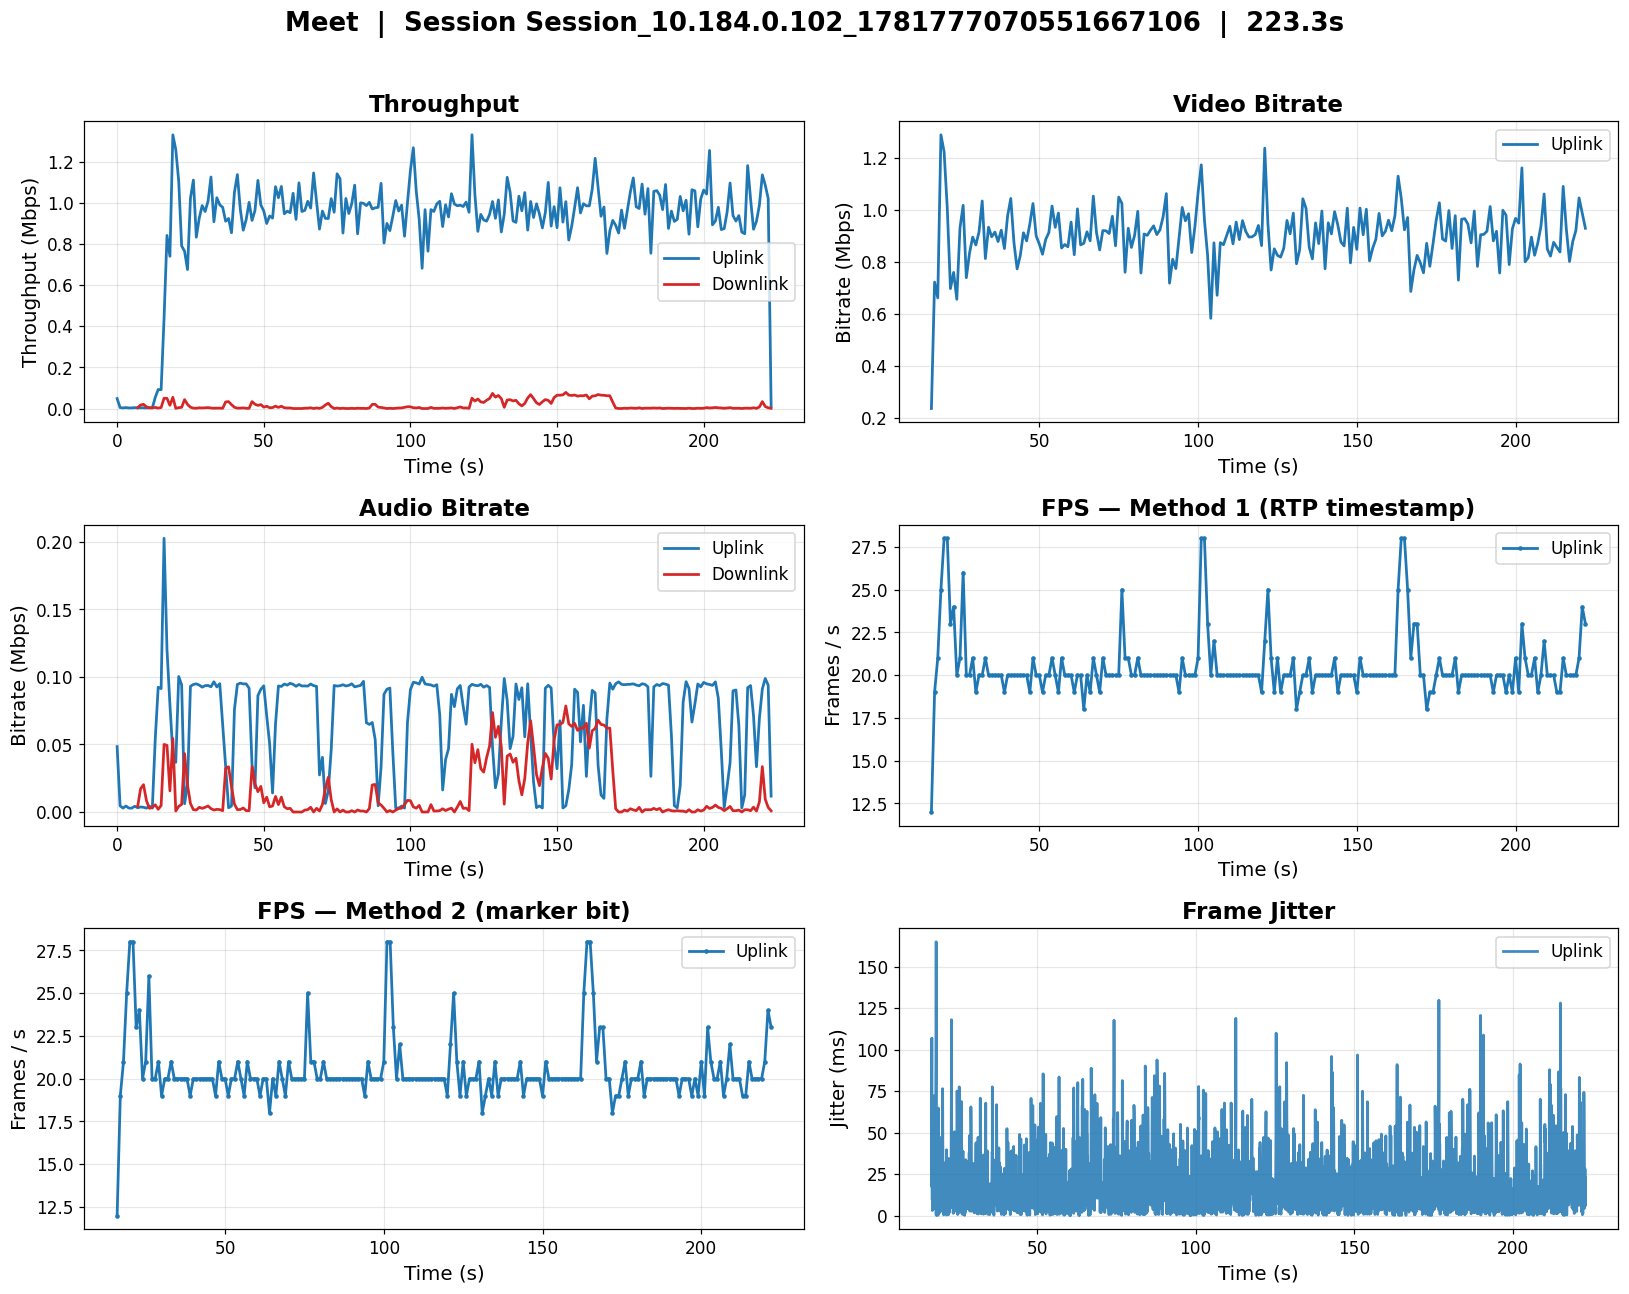

Per-session plots:   0%|          | 1/480 [00:02<17:45,  2.22s/fig]

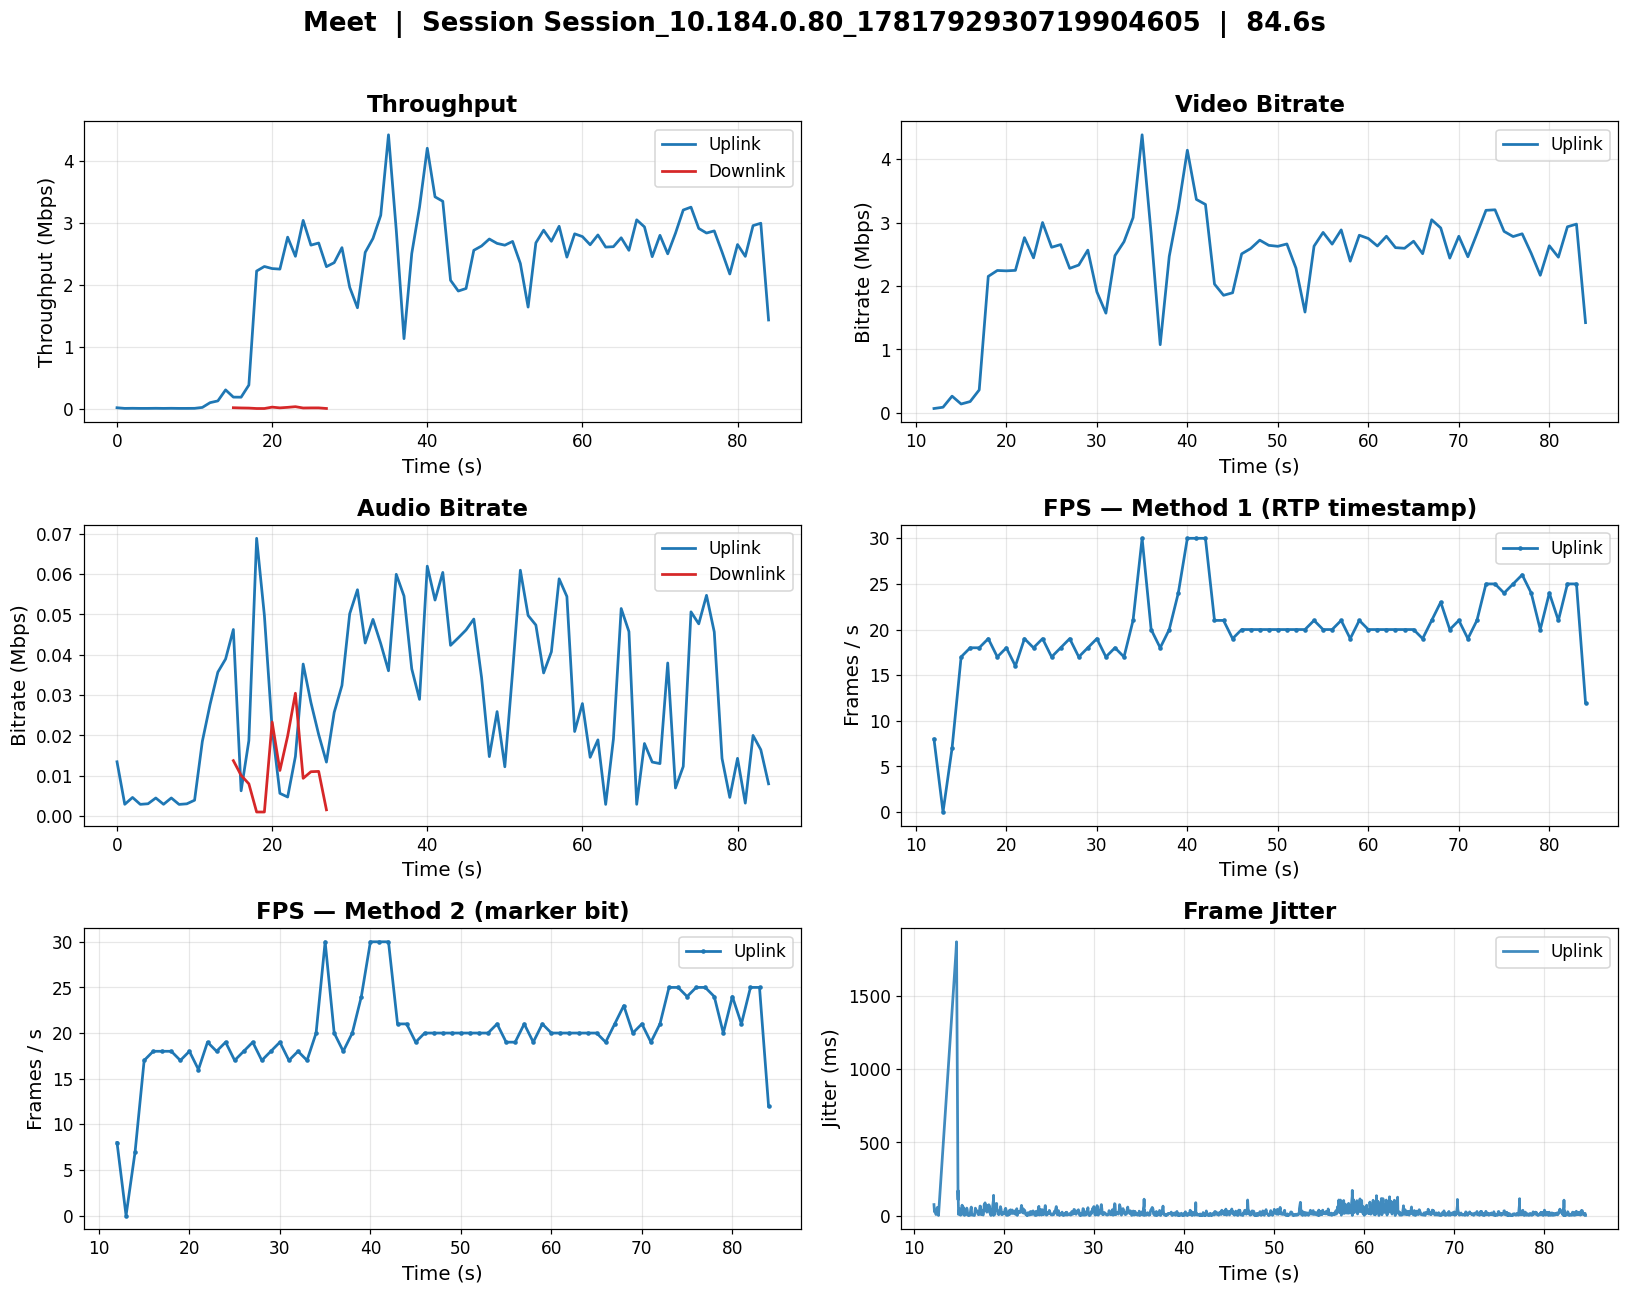

Per-session plots:   2%|▏         | 11/480 [00:14<09:21,  1.20s/fig]/tmp/ipykernel_2848303/2830479230.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.set_title("Video Bitrate"); ax.set_xlabel("Time (s)"); ax.set_ylabel("Bitrate (Mbps)"); ax.legend()
/tmp/ipykernel_2848303/2830479230.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.set_title("FPS — Method 1 (RTP timestamp)"); ax.set_xlabel("Time (s)"); ax.set_ylabel("Frames / s"); ax.legend()
/tmp/ipykernel_2848303/2830479230.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.set_title("FPS — Method 2 (marker bit)"); ax.set_xlabel("Time (s)"); ax

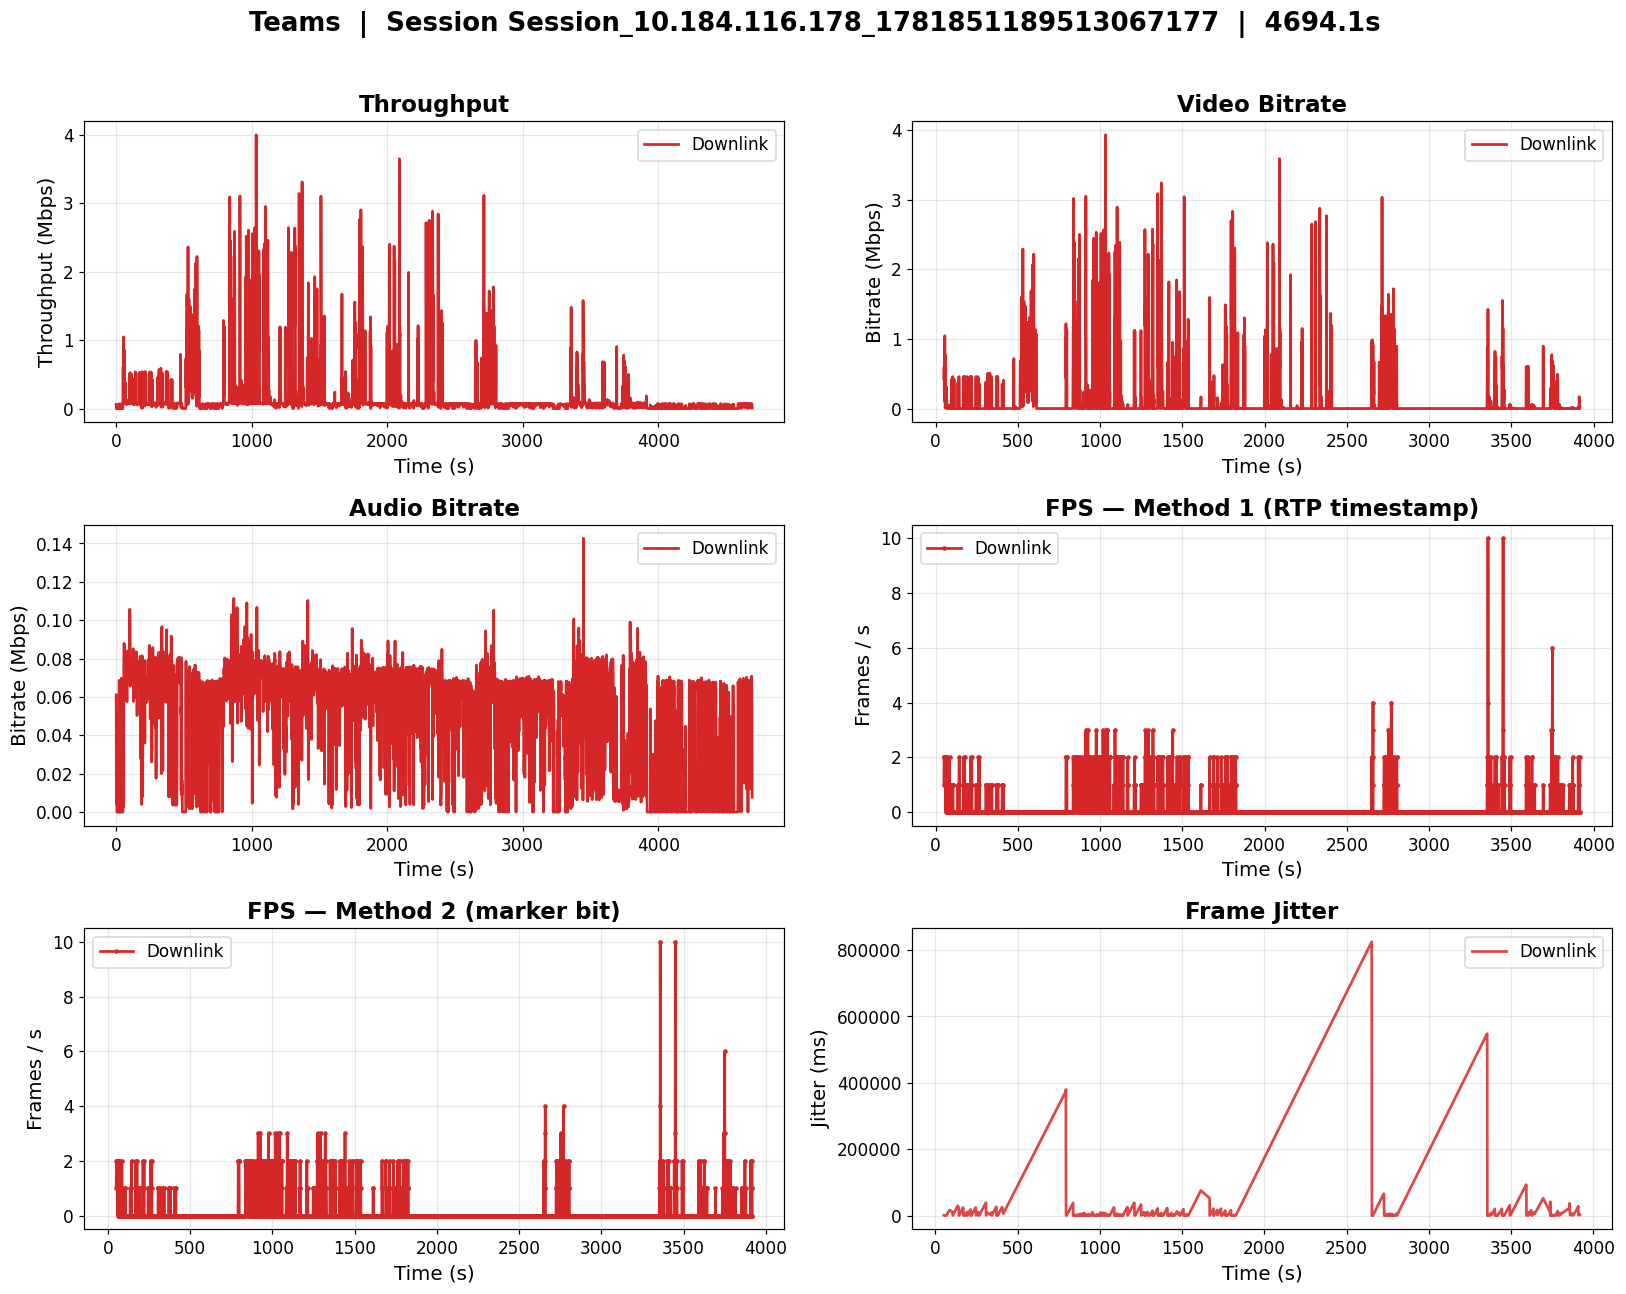

Per-session plots:  88%|████████▊ | 422/480 [08:20<01:19,  1.38s/fig]

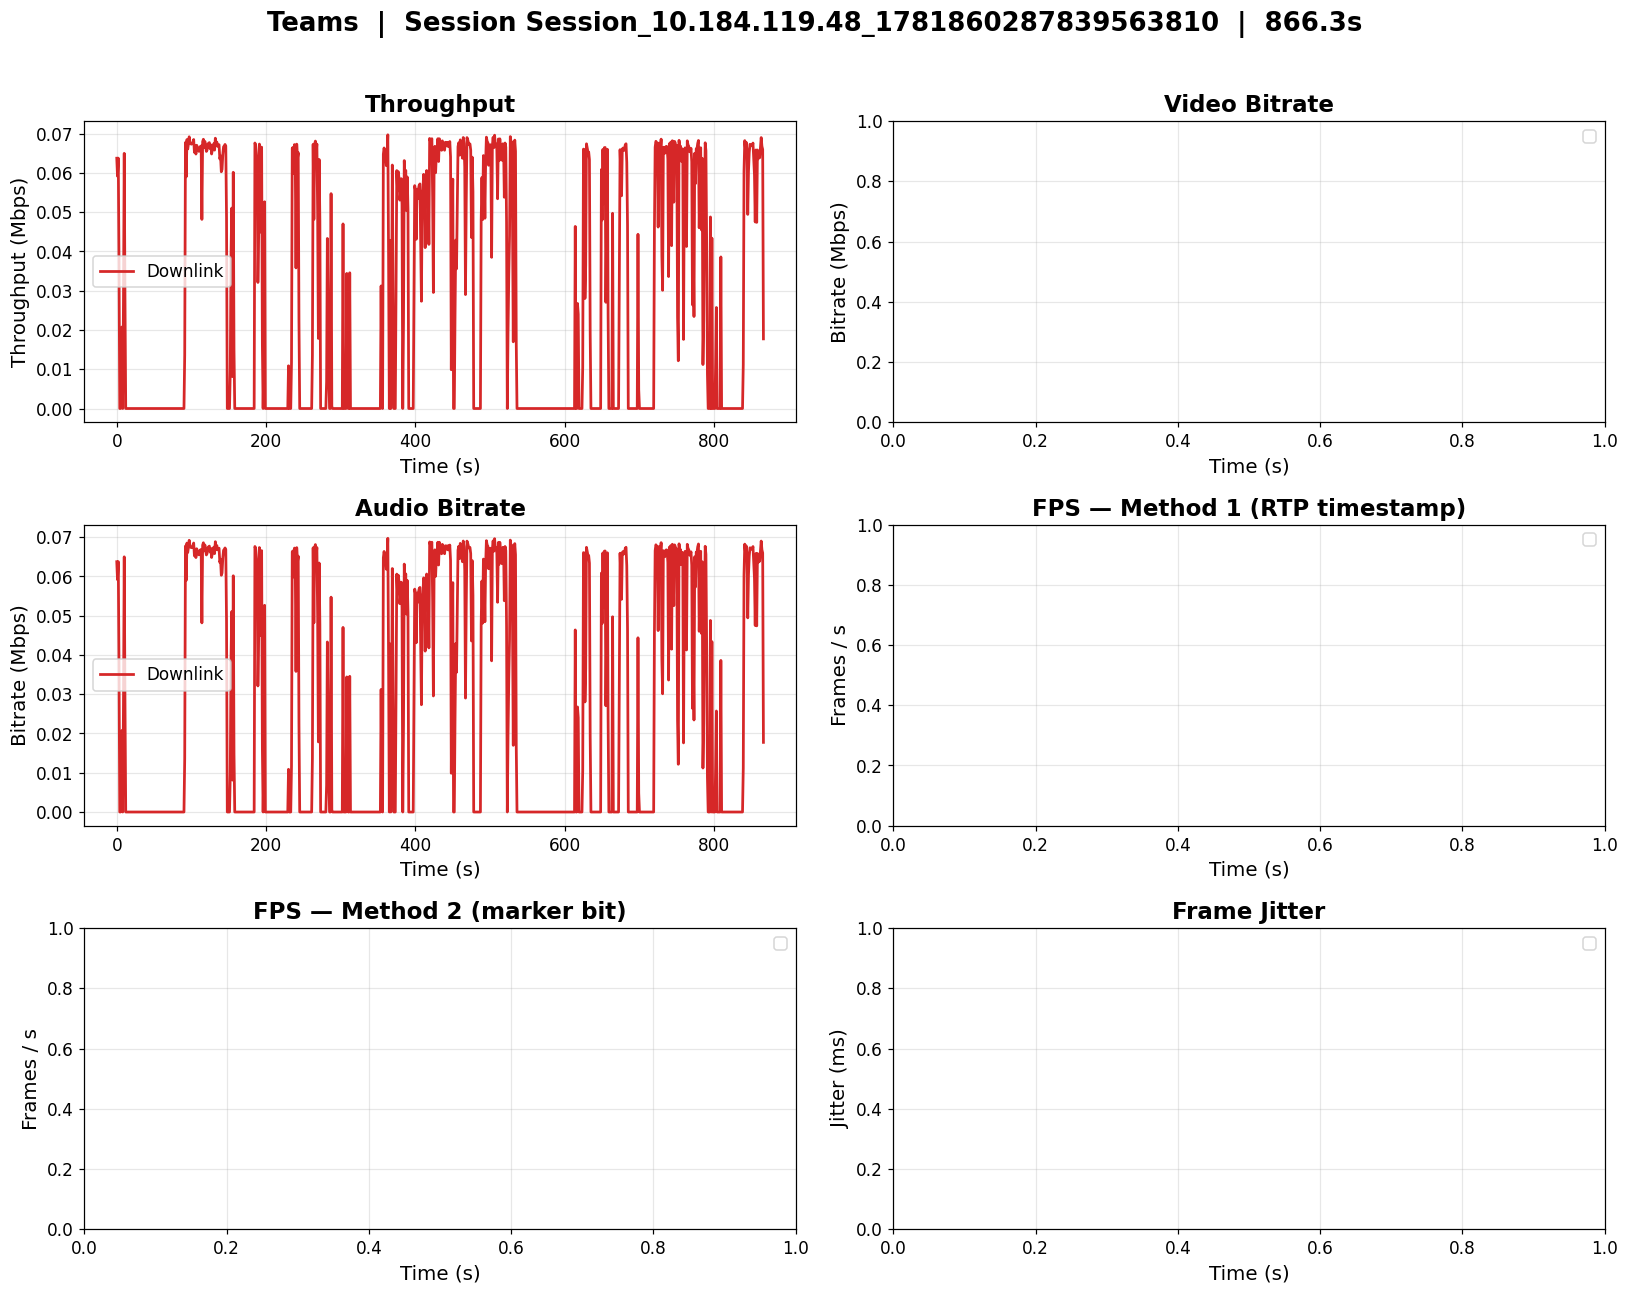

Per-session plots: 100%|██████████| 480/480 [09:30<00:00,  1.19s/fig]

Saved 480 figure(s) to analysis_output/per_session_plots/


In [19]:
save_all_session_plots(summary_df, ts_store, show_examples=2)

View any single session inline on demand:

Valid session IDs: ['Session_10.184.0.102_1781777070551667106', 'Session_10.184.0.80_1781792930719904605', 'Session_10.184.1.234_1781797547045029577', 'Session_10.184.10.74_1781785891780866942', 'Session_10.184.10.99_1781775048582157766', 'Session_10.184.10.99_1781775676717734355', 'Session_10.184.100.14_1781838663517041030', 'Session_10.184.100.31_1781859831261728260', 'Session_10.184.100.50_1781840239192337894', 'Session_10.184.103.215_1781845744621026659', 'Session_10.184.103.222_1781800989395852050', 'Session_10.184.104.111_1781842026026991341', 'Session_10.184.105.210_1781777681752941496', 'Session_10.184.106.244_1781802469701993419', 'Session_10.184.106.89_1781772935018377018', 'Session_10.184.106.89_1781798766821443882', 'Session_10.184.108.118_1781776807806364560', 'Session_10.184.108.118_1781777102959266921', 'Session_10.184.108.118_1781778836387783800', 'Session_10.184.11.157_1781778576859807549', 'Session_10.184.11.50_1781786035482210987', 'Session_10.184.11.77_1781848760692

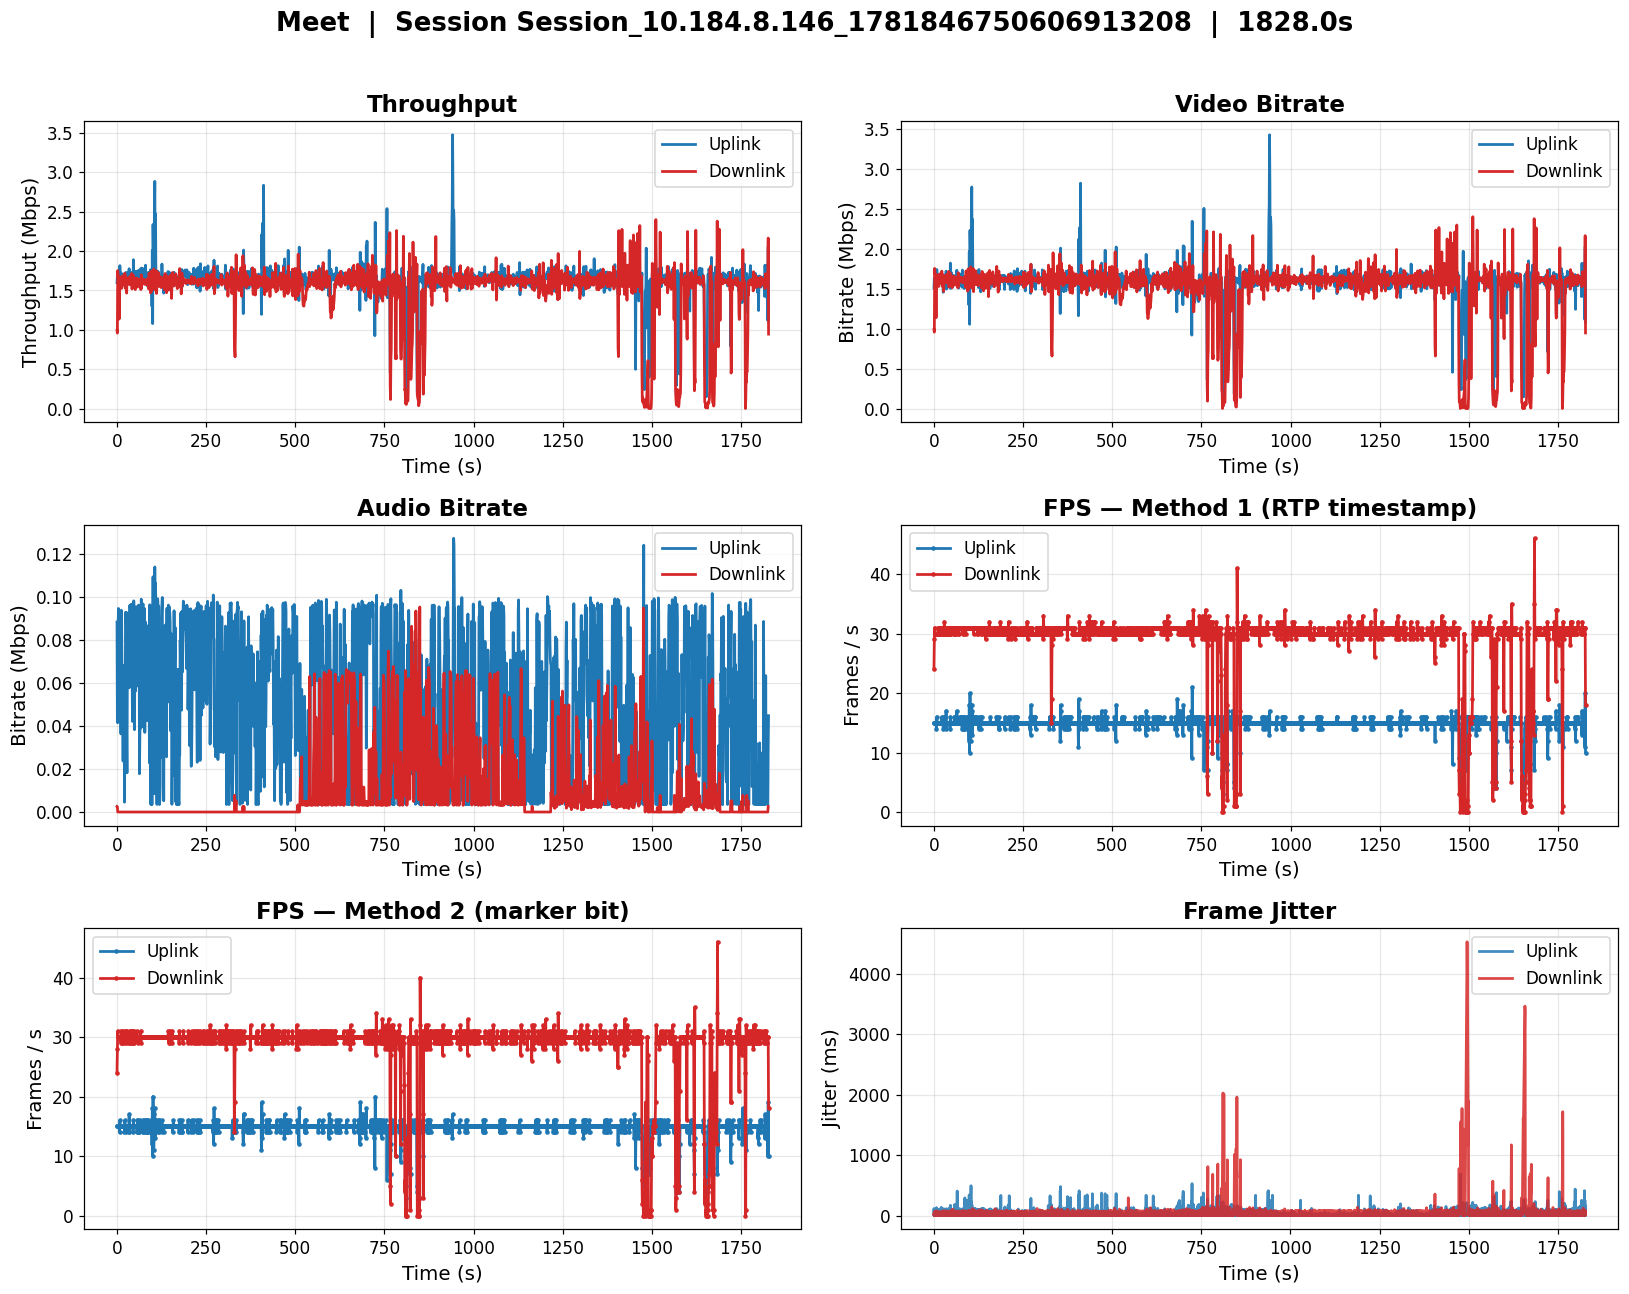

In [20]:
# Example: show the first valid session. Replace with any session_id from the table.
_valid_ids = summary_df.loc[summary_df["valid_session"], "session_id"].tolist()
print(f"Valid session IDs: {_valid_ids}")
if _valid_ids:
    show_session("Session_10.184.8.146_1781846750606913208", summary_df, ts_store)

## 10. Plots — Category 2: Cross-session statistics
Per platform, one point per session, for each metric (saved to `cross_session_plots/`).

## 11. Plots — Category 3: Teams vs Meet comparison
Aggregate means (grouped bars) plus distribution analysis: boxplots, histograms, CDFs.

In [ ]:
# platform_comparison_plots(summary_df, show=True)


# ============================================================================
# IEEE-STYLE Meet vs Teams Aggregate Comparison (FPS Method 1 only)
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# ----------------------------------------------------------------------------
# Filter valid sessions
# ----------------------------------------------------------------------------

_valid = (
    summary_df[summary_df["valid_session"]]
    if "valid_session" in summary_df.columns
    else summary_df[summary_df["duration_s"] > 30]
)

PLATFORMS = [
    p for p in ("Meet", "Teams")
    if (_valid["platform"] == p).any()
]

PCOLORS = {
    "Meet": "tab:orange",
    "Teams": "tab:purple"
}

# ----------------------------------------------------------------------------
# IEEE-friendly plotting style
# ----------------------------------------------------------------------------

plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.titlesize": 14
})

# ----------------------------------------------------------------------------
# Helper
# ----------------------------------------------------------------------------

def _panel(ax, title, ylabel, series, kind="grouped"):
    x = np.arange(len(PLATFORMS))

    if kind == "count":
        vals = [
            int((_valid["platform"] == p).sum())
            for p in PLATFORMS
        ]

        ax.bar(
            x,
            vals,
            width=0.55,
            color=[PCOLORS[p] for p in PLATFORMS]
        )

        ax.set_xticks(x)
        ax.set_xticklabels(PLATFORMS)

    else:
        width = 0.8 / max(len(series), 1)

        for i, (col, label) in enumerate(series):
            vals = [
                _valid.loc[
                    _valid["platform"] == p,
                    col
                ].mean(skipna=True)
                if col in _valid.columns else np.nan
                for p in PLATFORMS
            ]

            ax.bar(
                x + i * width,
                vals,
                width=width,
                label=label
            )

        ax.set_xticks(
            x + width * (len(series) - 1) / 2
        )
        ax.set_xticklabels(PLATFORMS)

        ax.legend(
            frameon=False,
            loc="best"
        )

    ax.set_title(title, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.grid(True, axis="y", alpha=0.3)
    ax.set_axisbelow(True)

# ----------------------------------------------------------------------------
# Figure
# ----------------------------------------------------------------------------

fig, axes = plt.subplots(
    3,
    3,
    figsize=(18, 12),
    constrained_layout=True
)

fig.suptitle(
    "Google Meet vs Microsoft Teams: Aggregate Session Comparison",
    fontweight="bold"
)

ax = axes.ravel()

# Number of sessions
_panel(
    ax[0],
    "Number of Sessions",
    "Count",
    [],
    kind="count"
)

# Session duration
_panel(
    ax[1],
    "Average Session Duration",
    "Seconds",
    [
        ("duration_s", "Duration")
    ]
)

# Throughput
_panel(
    ax[2],
    "Average Throughput",
    "Mbps",
    [
        ("uplink_throughput_mbps", "Uplink"),
        ("downlink_throughput_mbps", "Downlink")
    ]
)

# Peak throughput
_panel(
    ax[3],
    "Peak Throughput",
    "Mbps",
    [
        ("uplink_throughput_peak_mbps", "Uplink"),
        ("downlink_throughput_peak_mbps", "Downlink")
    ]
)

# Video bitrate
_panel(
    ax[4],
    "Average Video Bitrate",
    "Mbps",
    [
        ("uplink_video_bitrate_mbps", "Uplink"),
        ("downlink_video_bitrate_mbps", "Downlink")
    ]
)

# Audio bitrate
_panel(
    ax[5],
    "Average Audio Bitrate",
    "Mbps",
    [
        ("uplink_audio_bitrate_mbps", "Uplink"),
        ("downlink_audio_bitrate_mbps", "Downlink")
    ]
)

# FPS (Method 1 only)
_panel(
    ax[6],
    "Average FPS",
    "Frames/s",
    [
        ("uplink_fps_m1", "Uplink"),
        ("downlink_fps_m1", "Downlink")
    ]
)

# Jitter
_panel(
    ax[7],
    "Average Jitter",
    "ms",
    [
        ("uplink_jitter_ms", "Uplink"),
        ("downlink_jitter_ms", "Downlink")
    ]
)

# Packet Loss (NEW)
_panel(
    ax[8],
    "Average Packet Loss",
    "%",
    [
        ("uplink_loss_pct", "Uplink"),
        ("downlink_loss_pct", "Downlink")
    ]
)

# ----------------------------------------------------------------------------
# Save figure
# ----------------------------------------------------------------------------

save_path = os.path.join(
    COMPARE_DIR,
    "meet_vs_teams_overview_ieee.png"
)

fig.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved figure: {save_path}")

# ----------------------------------------------------------------------------
# Per-platform summary table
# ----------------------------------------------------------------------------

metric_cols = [
    "duration_s",
    "uplink_throughput_mbps",
    "downlink_throughput_mbps",
    "uplink_throughput_peak_mbps",
    "downlink_throughput_peak_mbps",
    "uplink_video_bitrate_mbps",
    "downlink_video_bitrate_mbps",
    "uplink_audio_bitrate_mbps",
    "downlink_audio_bitrate_mbps",
    "uplink_fps_m1",
    "downlink_fps_m1",
    "uplink_jitter_ms",
    "downlink_jitter_ms",
    "uplink_loss_pct",
    "downlink_loss_pct"
]

summary_platform = (
    _valid
    .groupby("platform")[metric_cols]
    .mean(numeric_only=True)
    .round(3)
)

summary_platform.insert(
    0,
    "n_sessions",
    _valid.groupby("platform").size()
)

print("\nPer-platform averages (valid sessions > 30s):\n")
display(summary_platform)

## 12. Outputs summary

In [ ]:
import glob as _g
print("Outputs under", OUTPUT_DIR + "/")
print("  metrics CSV          :", SUMMARY_CSV)
print("  skipped-files CSV    :", ERRORS_CSV, "(if any)")
print("  per-session figures  :", len(_g.glob(PER_SESSION_DIR + "/*.png")), "PNG ->", PER_SESSION_DIR + "/")
print("  cross-session figures:", len(_g.glob(CROSS_DIR + "/*.png")), "PNG ->", CROSS_DIR + "/")
print("  comparison figures   :", len(_g.glob(COMPARE_DIR + "/*.png")), "PNG ->", COMPARE_DIR + "/")

Outputs under analysis_output/
  metrics CSV          : analysis_output/session_summary.csv
  skipped-files CSV    : analysis_output/skipped_sessions.csv (if any)
  per-session figures  : 486 PNG -> analysis_output/per_session_plots/
  cross-session figures: 20 PNG -> analysis_output/cross_session_plots/
  comparison figures   : 0 PNG -> analysis_output/platform_comparison_plots/


## Notes & assumptions
- **Direction** by client IP (private/IIT-Delhi address from filename); other packets excluded.
- **Validity:** only sessions with `duration_s > 30` feed the table, plots, and stats.
- **Throughput/bitrate** use `ip_len`; set `BYTES_COL="udp_len"` for media-only.
- **FPS/jitter** are per dominant video SSRC, per direction. Method 1 = distinct RTP
  timestamps over the 90 kHz span (32-bit unwrapped); Method 2 = marker bits per second.
- **Progress & recovery:** `process_all` shows a tqdm bar (ETA, running counts) when
  `tqdm` is installed (`%pip install tqdm`), checkpoints the CSV every `checkpoint_every`
  files, and logs skipped files to `skipped_sessions.csv` / `errors_df`.
- After a kernel restart, Run -> Run All before the driver cell; the preflight check
  reports anything missing. Per-session figures are saved to disk; use `show_session(id,…)`
  to view one inline.